# 决策树处理分类任务

1.	使用sklearn.tree.DecisionTreeClassifier完成Breast_Cancer_Wisconsin数据集预测问题
2.	计算最大深度为10时，十折交叉验证的精度(accuracy)，查准率(precision)，查全率(recall)，F1值
3.	绘制最大深度从1到10的决策树十折交叉验证精度的变化图

## 1. 读取数据

In [1]:
import numpy as np
import pandas as pd
data = pd.read_csv('data/Breast_Cancer_Wisconsin/data.txt')
print(data.shape)

(569, 33)


In [2]:
data = data.values 
data_x = data[:,2:-1]
data_y = data[:,1:2]
data_y = np.reshape(data_y,(-1))

print(data_x.shape)
print(data_y.shape)

(569, 30)
(569,)


## 2. 导入模型

In [3]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier

## 3. 训练与预测
计算最大深度为10的决策树，在使用数据data_x，标记data_y下，十折交叉验证的精度，查准率，查全率和F1值

In [4]:
model = DecisionTreeClassifier(max_depth = 10) # 参数max_depth决定了决策树的最大深度
prediction = cross_val_predict(model, data_x, data_y, cv=10)
print('accuracy:', accuracy_score(data_y, prediction))
print('precision:', precision_score(data_y, prediction, pos_label='M'))
print('recall:', recall_score(data_y, prediction, pos_label='M'))
print('F1:', f1_score(data_y, prediction, pos_label='M'))






accuracy: 0.9156414762741653
precision: 0.8796296296296297
recall: 0.8962264150943396
F1: 0.8878504672897196


###### 双击此处填写下面的表格

最大深度为10：  

精度 | 查准率 | 查全率 | F1
-|-|-|-
0.9156414762741653 | 0.8796296296296297 | 0.8962264150943396| 0.8878504672897196

## 4. 改变最大深度，绘制决策树的精度变换图

绘制最大深度从1到10，决策树十折交叉验证精度的变化图

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
y = []
for i in range(10):
    model = DecisionTreeClassifier(max_depth=i + 1)
    prediction = cross_val_predict(model, data_x, data_y, cv=10)
    y.append(prediction)

x = np.linspace(1,10,10)
test = [accuracy_score(data_y, prediction) for prediction in y]


Text(0, 0.5, 'accuracy_score')

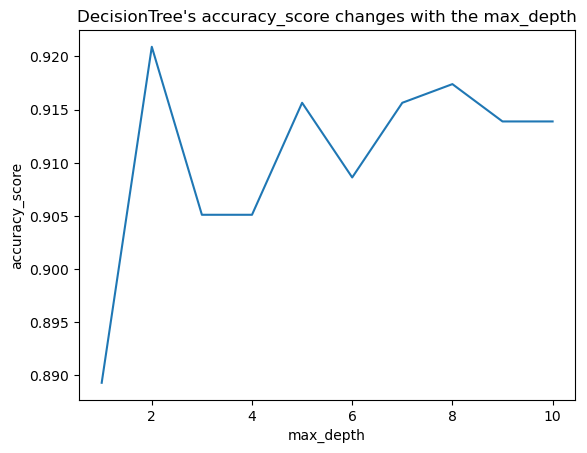

In [7]:
plt.figure()
plt.plot(x,test,'-')
plt.title("DecisionTree's accuracy_score changes with the max_depth")
plt.xlabel("max_depth")    
plt.ylabel("accuracy_score")

# 5. （选做）通过调整参数，得到一个泛化能力最好的模型

查看决策树文档，通过调整决策树的参数，得到一个最好的模型  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier  
并在下方给出参数的设定与其泛化性能指标

**（选做仅供参考）**

使用的GridSearchCV，它存在的意义就是自动调参，只要把参数输进去，就能给出最优化的结果和参数。
但是这个方法适合于小数据集，一旦数据的量级上去了，很难得出结果。

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
modelfit = DecisionTreeClassifier(max_depth=10, random_state=42)
param_grid = {'criterion':['gini','entropy'],'max_depth':[10,11,12],
                  'min_samples_leaf':[1,2,3,4,5],'max_features':[1,2,3,4,5],'min_samples_split':[2,3,4,5]}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(modelfit, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(data_x, data_y)
best_prediction = cross_val_predict(grid_search.best_estimator_, data_x, data_y, cv=cv)
print('best parameters:', grid_search.best_params_)
print('accuracy:', accuracy_score(data_y, best_prediction))
print('precision:', precision_score(data_y, best_prediction, pos_label='M'))
print('recall:', recall_score(data_y, best_prediction, pos_label='M'))
print('F1:', f1_score(data_y, best_prediction, pos_label='M'))

best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
accuracy: 0.9490333919156415
precision: 0.9295774647887324
recall: 0.9339622641509434
F1: 0.9317647058823529


###### 双击此处填写下面的表格

最大深度为10：  

精度 | 查准率 | 查全率 | F1
-|-|-|-
0.9490333919156415 | 0.9295774647887324 | 0.9339622641509434 | 0.9317647058823529